<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/K_Prototypes_para_datos_de_comportamiento_de_compras_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

Se trata del conjunto de datos con mil registros con cuatro variables numéricas y cuatro variables categóricas. Se hace una implementación de modelo de clustering mediante modelo *K-Prototypes* dada la existencia de variables numéricas y categóricas.

Las variables numéricas del conjunto de datos son:

* *edad* años cumplidos del cliente,
* *ingreso* que representa precisamente el ingreso económico comprobado del cliente;
* *visitasmes* es la cantidad promedio de visitas que hace un cliente o que compra al mes;
* *gasto* es el monto económico que un cliente gasta al mes por concepto de compras.

Las variables categóricas son:           
* *canal* que es el medio por el cual un cliente adquiere los productos: *App*, *Tienda*, *Web* o *Telefono*;
* *region* la localización regional en donde se reporta que radica el cliente: *Centro*, *Norte*, *Occidente* o *Sur*;
* *satisfaccion* el nivel de satisfacción en las compras del cliente: *Alta*, *Media* o *Baja*;
* *promocion"* El nivel de respuesta que el cliente tiene ante promociones: *Alta*, *Media* o *Baja*.

Luego, el conjunto de datos contiene dos variables que son descartadas para el modelo como *id* y *perfil_simulado* no considerados para los modelos.

El documento se puede encontrar en https://colab.research.google.com/drive/1iGDF-lJNwTu443z7pTbWH69S5_Es-Pnx?usp=sharing .

Tambien puede encontrarse en la plataformna *github.com* en https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/K_Prototypes_para_datos_de_comportamiento_de_compras_de_clientes.ipynb .

Los datos pueden descargarse desde el servicio *github.com* en https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_clientes_kprototypes_1000.csv .

Las funciones puede encontrase en https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20K-Prototype.py .




# Objetivo

Implementar y evaluar modelos *K-Prototypes* para dos y tres clústeres para datos de comportamiento de compras de clientes.

Se evalúa el menor costo de similitud para sugerir el mejor modelo habiendo implementado *K-Prototypes*.


# Descripción

## Cargar librerías

In [1]:
!pip install kmodes

In [2]:
import numpy as np   # Para estructuras de datos
import pandas as pd  # Cargar conjuntos de datos
import matplotlib.pyplot as plt # Visualizar
import math # Funciones matemáticas
import itertools # Para iteraciones o ciclos
import seaborn as sns   # Gráficos

from kmodes.kprototypes import KPrototypes
from matplotlib.ticker import PercentFormatter # Graficos depurados
from sklearn.preprocessing import StandardScaler, MinMaxScaler # Escalar datos

## Cargar funciones


In [3]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20K-Prototype.py"
import requests

exec(requests.get(url).text)

## Cargar datos

Con la función *f_cargar_datos()* se cargan los datos originales y solo se seleccionas las variables de interés *edad*, *ingreso*, *visitasmes*, *gasto*, *canal*, *region*, *satisfaccion* y *promocion*.

Con la función *f_visualizar_head_tail_reducido()* se presentan los primeros y últimos registros.


In [4]:
datos = f_cargar_datos("https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_clientes_kprototypes_1000.csv")
datos = datos[["edad", "ingreso", "visitasmes", "gasto", "canal", "region", "satisfaccion","promocion"]]

f_visualizar_head_tail_reducido(datos)

,edad,ingreso,visitasmes,gasto,...,canal,region,satisfaccion,promocion
0,37,27314,6,1029,...,App,Centro,Baja,Alta
1,33,20752,5,879,...,Tienda,Norte,Alta,Baja
2,58,18618,7,920,...,Web,Occidente,Baja,Media
3,41,19504,4,1311,...,Web,Centro,Alta,Media
4,22,28646,10,400,...,App,Occidente,Media,Media
5,43,42390,16,3699,...,App,Norte,Alta,Media
6,...,...,...,...,...,...,...,...,...
7,42,24809,2,183,...,Telefono,Occidente,Baja,Baja
8,47,49053,18,2887,...,App,Norte,Alta,Media
9,26,48145,20,3198,...,Web,Norte,Media,Media


## Estadísticos descriptivos de variables numéricas

Se presentan los estadísticos descriptivos de las variables numéricas.


In [5]:
variables_numericas=["edad", "ingreso", "visitasmes", "gasto"]
f_describir_datos(datos[variables_numericas])

{'describe':              count       mean         std     min       25%      50%      75%  \
 edad        1000.0     37.779     11.1956    18.0     29.00     37.0     45.0   
 ingreso     1000.0  27185.342  11889.1230  5000.0  18648.75  24830.5  33903.0   
 visitasmes  1000.0      7.850      4.9279     0.0      4.00      7.0     11.0   
 gasto       1000.0   1592.775   1098.9411   100.0    769.50   1294.0   2159.0   
 
                 max  
 edad           75.0  
 ingreso     70936.0  
 visitasmes     22.0  
 gasto        5245.0  ,
 'frecuencias': {},
 'structure': edad          int64
 ingreso       int64
 visitasmes    int64
 gasto         int64
 dtype: object}

## Frecuencias de clases de variables categóricas

Se presentan las frecuencias de las variables categóricas *canal*, *region*, *satisfaccion* y *promocion* con la función *f_frecuencias_clases()*.

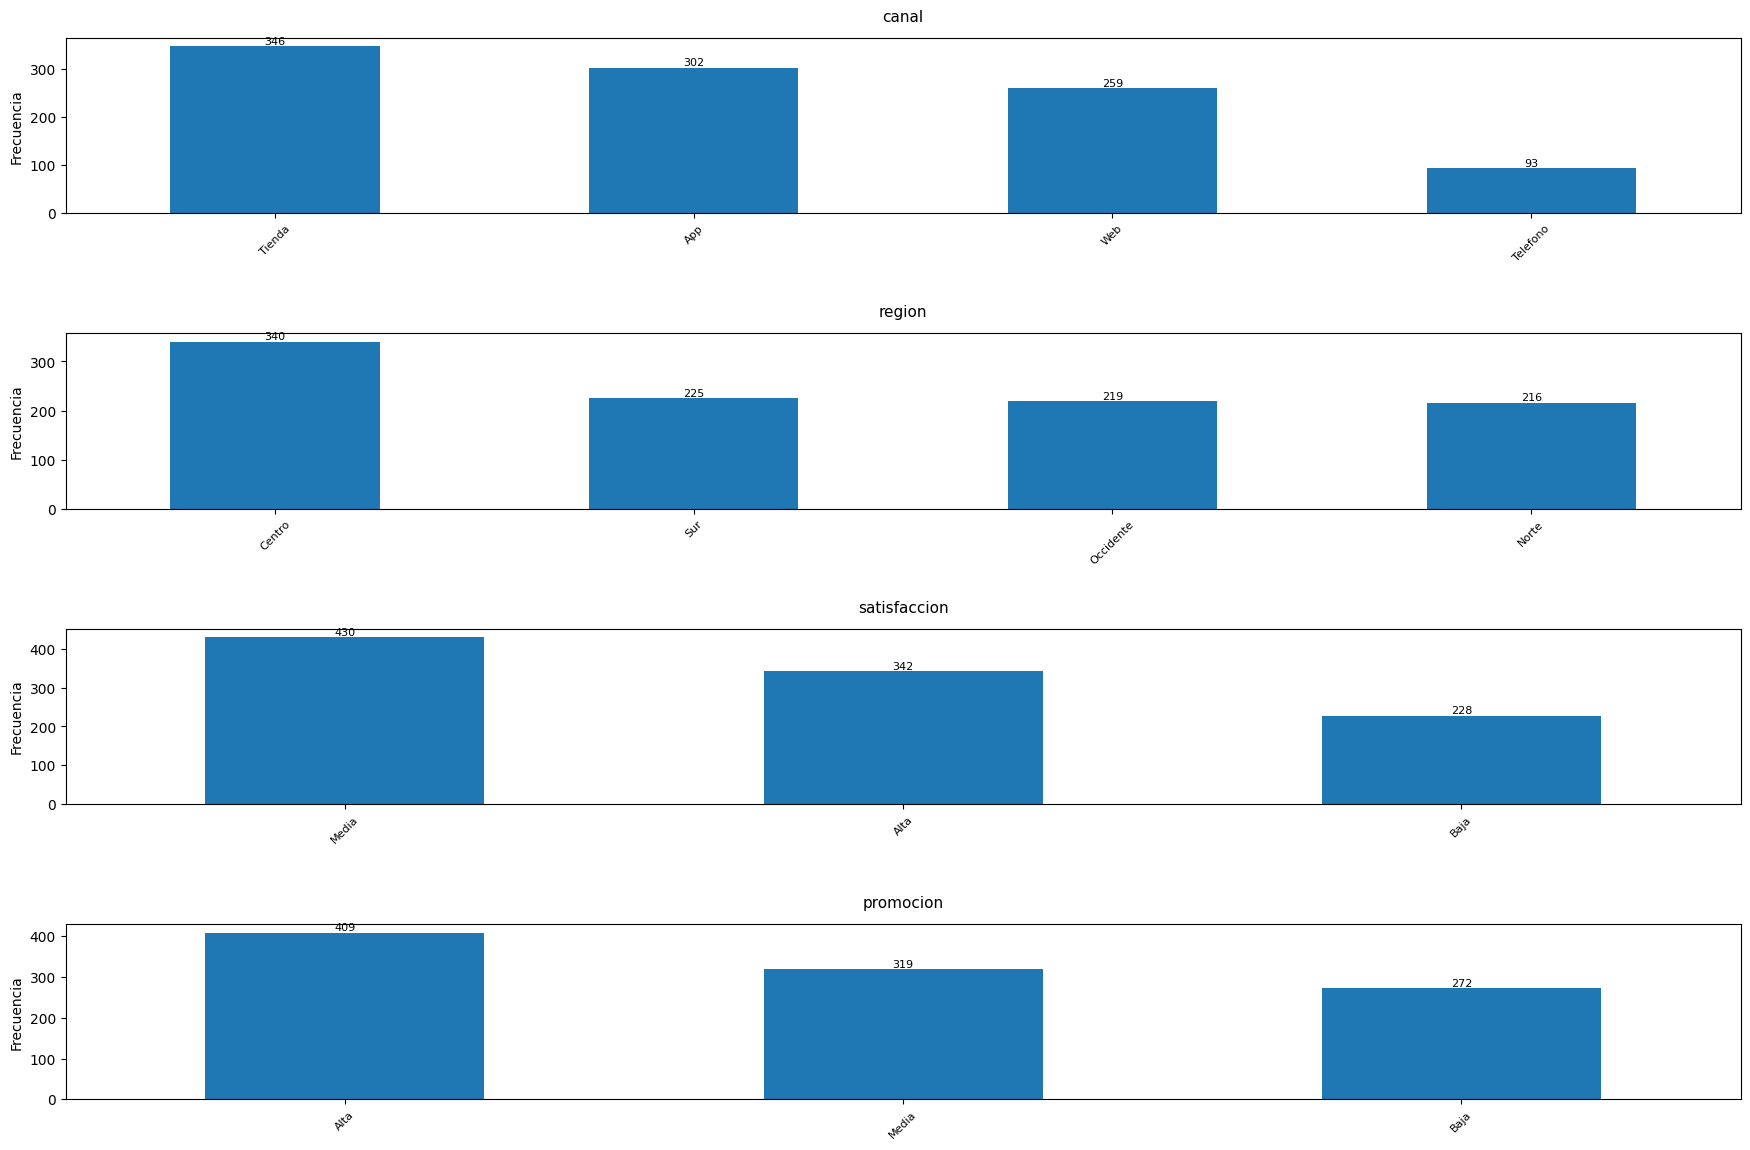

In [6]:
variables_categoricas=["canal", "region", "satisfaccion", "promocion"]
f_frecuencias_clases(datos[variables_categoricas])

## Estandarización de datos

Se estandarizan las variables numéricas con la función *f_estandarizar_escalar()* del conjunto de datos original; se crea una copia de los datos estandarizados para luego adherir las variables categóricas originales y dejar el conjunto de datos en uno nuevo llamado *datos_kprototypes* listo para los modelos basados el el algoritmo *K-Prototypes*.



In [7]:
resultado = f_estandarizar_escalar(
    datos = datos,
    variables_numericas = variables_numericas
)

escalador_est = resultado["escalador_est"] # Se necesita el escalador
# escalador_minmax = resultado["escalador_minmax"]

datos_estandarizados = resultado["datos_estandarizados"]
# datos_escalados = resultado["datos_escalados"]

datos_kprototypes = datos_estandarizados.copy()
datos_kprototypes[variables_categoricas] = datos[variables_categoricas].copy()
f_visualizar_head_tail_reducido(datos_kprototypes)

,edad,ingreso,visitasmes,gasto,...,canal,region,satisfaccion,promocion
0,-0.0696,0.0108,-0.3756,-0.5133,...,App,Centro,Baja,Alta
1,-0.4271,-0.5414,-0.5786,-0.6498,...,Tienda,Norte,Alta,Baja
2,1.8071,-0.721,-0.1726,-0.6125,...,Web,Occidente,Baja,Media
3,0.2878,-0.6464,-0.7817,-0.2565,...,Web,Centro,Alta,Media
4,-1.4101,0.1229,0.4365,-1.0859,...,App,Occidente,Media,Media
5,0.4666,1.2795,1.6547,1.9176,...,App,Norte,Alta,Media
6,...,...,...,...,...,...,...,...,...
7,0.3772,-0.2,-1.1877,-1.2835,...,Telefono,Occidente,Baja,Baja
8,0.824,1.8402,2.0607,1.1783,...,App,Norte,Alta,Media
9,-1.0526,1.7638,2.4668,1.4614,...,Web,Norte,Media,Media


# Desarrollo

Se construye modelos *K-Prototypes* para *K=2* y *K=3* clústeres.

## K-Prototypes para K=2

Se construye con el modelo *K-Prototypes* con dos clústeres y los argumentos que se envían a la función *f_crear_KPrototypes()*.  


In [8]:
modelo_KPrototypesK2 = f_crear_KPrototypes(
    datos=datos_kprototypes, # Los datos fuente para el modelo
    variables_numericas=variables_numericas,
    variables_categoricas=variables_categoricas,
    n_clusters=2, # K=2
    init="Huang", # Es el método para seleccionar los prototipos iniciales.
    n_init=25, # cuántas veces se ejecuta el algoritmo con diferentes inicializaciones.
    max_iter=100, # Se termina con 100 iteraciones máximo
    gamma=None, # Default 1, el valor del peso de disimilitud en vars categóricas
    random_state=2026, # Aleatoriedad y replicabilidad en el algoritmo
    estandarizar=False, # Ya vienen estandarizados, en caso contrario True
    nombre_cluster="cluster_KPrototypesK2" # solo como etiqueta
)




### Prototipos o clústeres finales K=2 y asignación de clústeres



In [9]:
modelo_KPrototypesK2["prototipos_finales"]

,cluster,edad,ingreso,visitasmes,gasto,canal,region,satisfaccion,promocion
0,1,-0.202346,1.113917,1.126146,1.229276,App,Centro,Alta,Alta
1,2,0.088800,-0.488841,-0.494211,-0.539466,Tienda,Centro,Media,Baja


Se asigna el cluster para cada registro del conjunto de datos que se usó para el modelo.

Los clústeres se extraen del modelo *modelo_KPrototypesK2["cluster"]* y son son asignados a cada registro del conjunto de datos *modelo_KPrototypesK2*.

In [10]:
datos_kprototypesK2 = datos_kprototypes.copy() # Para K2
datos_kprototypesK2['cluster_prototype'] = modelo_KPrototypesK2["cluster"]
f_visualizar_head_tail_reducido(datos_kprototypesK2)

,edad,ingreso,visitasmes,gasto,...,region,satisfaccion,promocion,cluster_prototype
0,-0.0696,0.0108,-0.3756,-0.5133,...,Centro,Baja,Alta,2
1,-0.4271,-0.5414,-0.5786,-0.6498,...,Norte,Alta,Baja,2
2,1.8071,-0.721,-0.1726,-0.6125,...,Occidente,Baja,Media,2
3,0.2878,-0.6464,-0.7817,-0.2565,...,Centro,Alta,Media,2
4,-1.4101,0.1229,0.4365,-1.0859,...,Occidente,Media,Media,2
5,0.4666,1.2795,1.6547,1.9176,...,Norte,Alta,Media,1
6,...,...,...,...,...,...,...,...,...
7,0.3772,-0.2,-1.1877,-1.2835,...,Occidente,Baja,Baja,2
8,0.824,1.8402,2.0607,1.1783,...,Norte,Alta,Media,1
9,-1.0526,1.7638,2.4668,1.4614,...,Norte,Media,Media,1


### Dispersión de pares de variables numéricas K-Prototypes K=2

La visualización de la dispersión se hace con la función *f_dispersion_variables_clusters()*. La **grafica** muestra la relación entre variables numéricas por pares y los clústeres creados del modelo *K-Prototypes* con *K=2, se observa que el modelo separa a los clientes principalmente en función de variables asociadas con el valor comercial.

El *clúster 1* concentra clientes con mayores niveles relativos de ingreso, visitas mensuales y gasto promedio, mientras que el clúster 2 agrupa clientes con valores menores en dichas variables.

La edad presenta una mayor mezcla y poca incidencia entre los grupos, por lo que no parece ser el principal factor de diferenciación.

Finalmente, el agrupamiento se explica principalmente por variables económicas y de comportamiento de compra, lo que permite interpretar los clústeres como clientes de alto valor comercial y clientes de menor actividad comercial o  de bajo consumo.



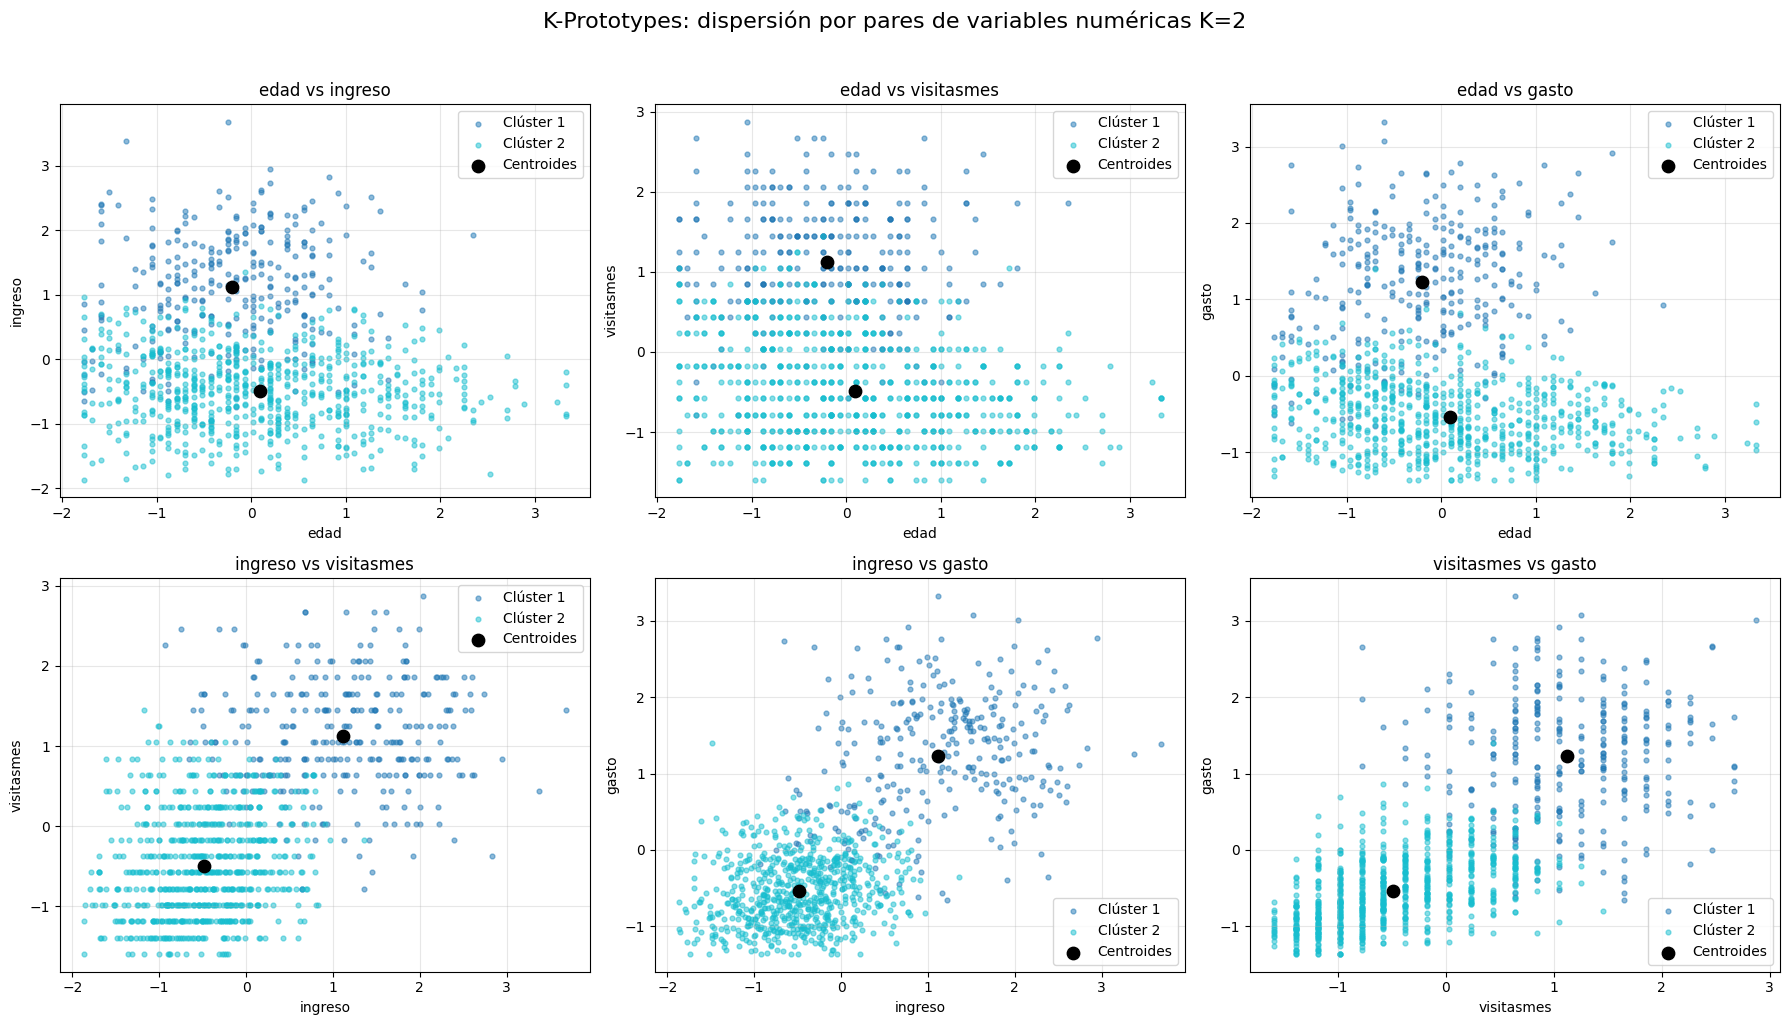

In [11]:
datos_visual = datos_kprototypesK2.copy()

datos_visual["cluster_prototype"] = modelo_KPrototypesK2["cluster"]


tabla_centroides = modelo_KPrototypesK2["prototipos_modelo"]

f_dispersion_variables_clusters(
    datos=datos_visual,
    variable_cluster="cluster_prototype",
    variables=variables_numericas,
    centroides=tabla_centroides[variables_numericas],
    titulo="K-Prototypes: dispersión por pares de variables numéricas K=2",
    ncol=3
)

plt.show()

### Diagramas de cajas K-Prototypes para variables numéricas K=2

En el diagrama de cajas que relaciona las variables numéricas con los clústeres asignados, se observa que efectivamente son las variables de tipo económico las que representan a los dos grupos. Los valores altos al *clúster 1* y los valores bajos al *clúster 2*. La *edad* no es relevante para definir los ambos clústeres.

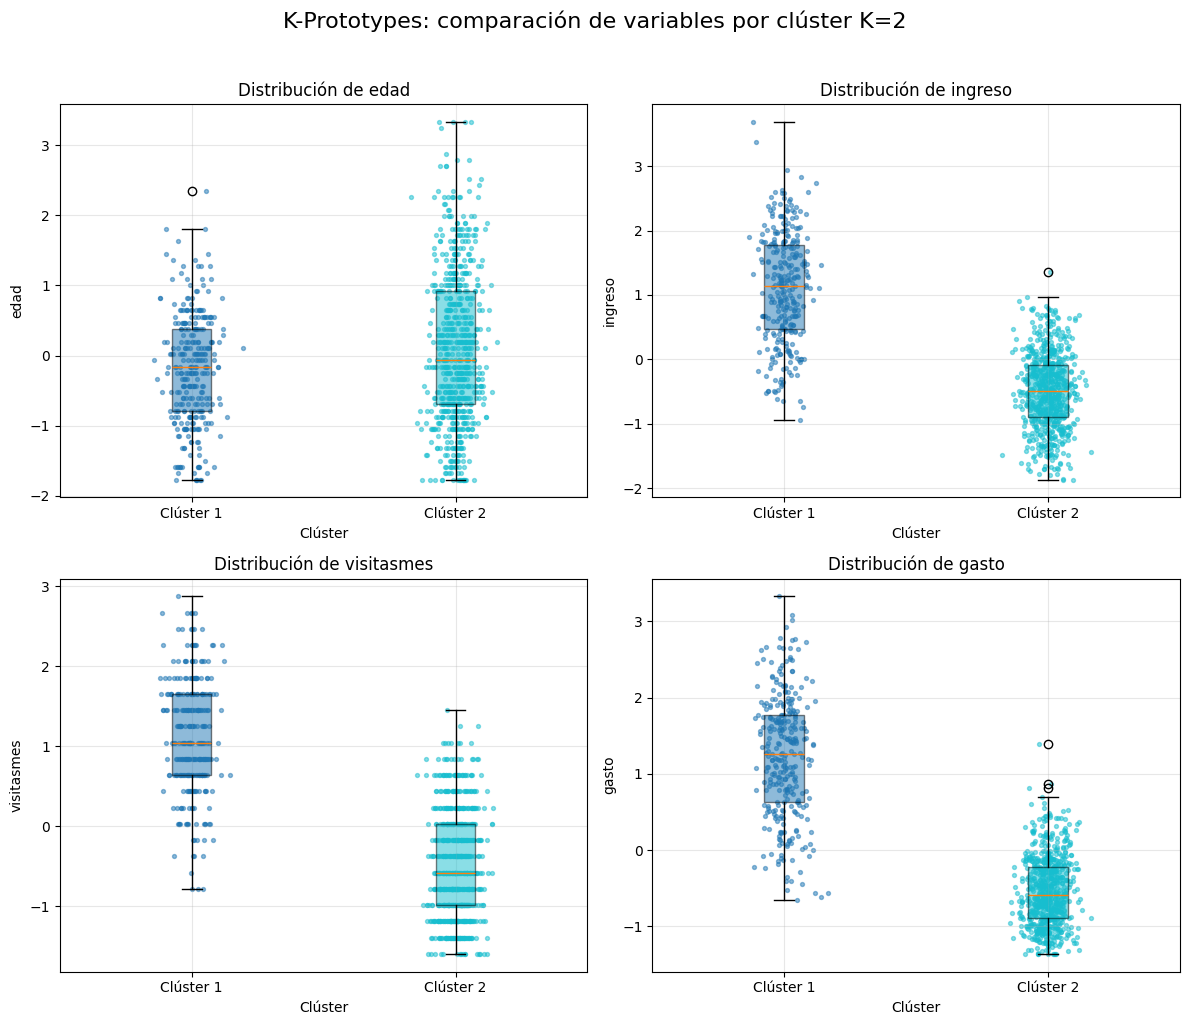

In [12]:
f_diagramas_cajas(
    datos=datos_kprototypesK2,
    variable_cluster="cluster_prototype",
    variables=variables_numericas,
    titulo="K-Prototypes: comparación de variables por clúster K=2",
    ncol=2
)

plt.show()

### Frecuencias de variables categóricas por cluster K=2

El *clúster 1* está principalmente definido por los clientes que compran sus productos via *App* y *Web* además de que son sensibles y con satisfacci[on de compras *Alta* así como reactivos a promociones de compras.

El *clúster 2* está conformado principalemnte por compradores que acuden a consumir directgamente en tiendas.



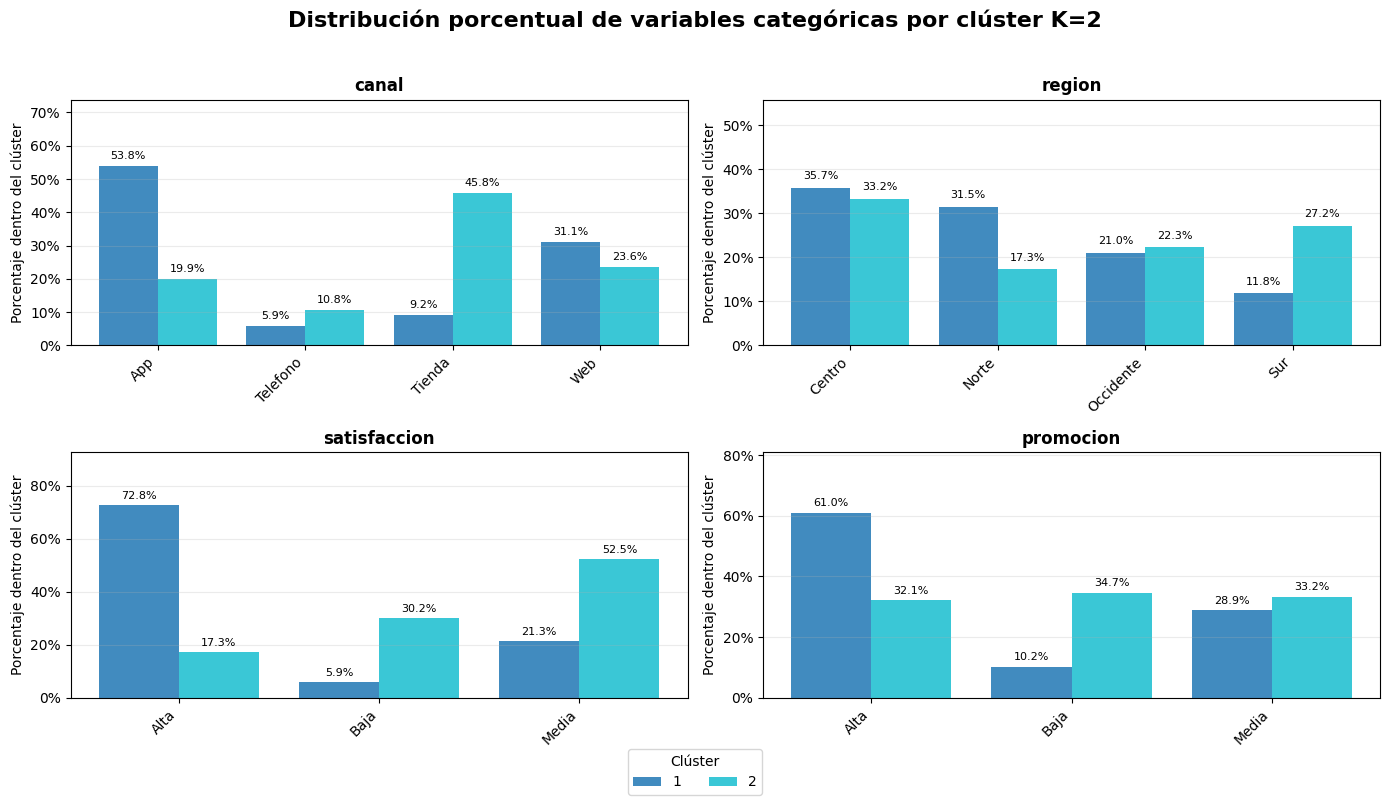

In [13]:
datos_visual = datos_kprototypesK2.copy()
cluster2 = modelo_KPrototypesK2.get("cluster")
datos_visual["cluster_KModesK2"] = cluster2

resultado_visual = f_visualizar_clusters_categoricos(
    datos=datos_visual,
    variable_cluster="cluster_KModesK2",
    variables=variables_categoricas,
    ncol=2,
    titulo="Distribución porcentual de variables categóricas por clúster K=2",
    posicion="dodge",
    mostrar_etiquetas=True,
    rotar_etiquetas=True
)


## K-Prototypes para K=3

Se construye con el modelo K-Prototypes con dos clústeres y los argumentos que se envían a la función *f_crear_KPrototypes()* para *K=3*.

In [14]:
modelo_KPrototypesK3 = f_crear_KPrototypes(
    datos=datos_kprototypes,
    variables_numericas=variables_numericas,
    variables_categoricas=variables_categoricas,
    n_clusters=3,
    init="Huang",
    n_init=25,
    max_iter=100,
    gamma=None,
    random_state=2026,
    estandarizar=False, # Ya vienen estandarizados
    nombre_cluster="cluster_KPrototypes"
)

### Prototipos o clústeres finales K=3

In [15]:
modelo_KPrototypesK3["prototipos_finales"]

,cluster,edad,ingreso,visitasmes,gasto,canal,region,satisfaccion,promocion
0,1,-0.076891,1.297255,1.188823,1.419716,App,Norte,Alta,Alta
1,2,0.875575,-0.600948,-0.791472,-0.719014,Tienda,Sur,Media,Baja
2,3,-0.739395,-0.315791,-0.072103,-0.290240,Web,Centro,Media,Alta


Se asigna el *clúster* para cada registro del conjunto de datos que se usó para el modelo.

Los clústeres se extraen del modelo *modelo_KPrototypesK3["cluster"]* y son son asignados a cada registro del conjunto de datos.

Se utiliza copia de *datos_kprototypes* en *datos_kprototypesK3* para no afectar los datos fuentes del modelo.

In [16]:
datos_kprototypesK3 = datos_kprototypes.copy() # Para K3
datos_kprototypesK3['cluster_prototype'] = modelo_KPrototypesK3["cluster"]
f_visualizar_head_tail_reducido(datos_kprototypesK3)

,edad,ingreso,visitasmes,gasto,...,region,satisfaccion,promocion,cluster_prototype
0,-0.0696,0.0108,-0.3756,-0.5133,...,Centro,Baja,Alta,3
1,-0.4271,-0.5414,-0.5786,-0.6498,...,Norte,Alta,Baja,3
2,1.8071,-0.721,-0.1726,-0.6125,...,Occidente,Baja,Media,2
3,0.2878,-0.6464,-0.7817,-0.2565,...,Centro,Alta,Media,2
4,-1.4101,0.1229,0.4365,-1.0859,...,Occidente,Media,Media,3
5,0.4666,1.2795,1.6547,1.9176,...,Norte,Alta,Media,1
6,...,...,...,...,...,...,...,...,...
7,0.3772,-0.2,-1.1877,-1.2835,...,Occidente,Baja,Baja,2
8,0.824,1.8402,2.0607,1.1783,...,Norte,Alta,Media,1
9,-1.0526,1.7638,2.4668,1.4614,...,Norte,Media,Media,1


### Dispersión de pares de variables numéricas K-Prototypes K=3

La visualización de la Figura 8 34, del modelo K-Prototypes con K=3 describe una clasificación más detallada de los clientes.

El *clúster 1* agrupa clientes con mayores niveles relativos de ingreso, visitas mensuales y gasto promedio, por lo que puede interpretarse como un grupo de alto valor comercial.

El *clúster 2* agrupa clientes con menores niveles en dichas variables, asociado con un perfil de bajo consumo o baja actividad comercial.

El *clúster 3* ocupa una posición intermedia, con valores moderados de ingreso, visitas y gasto.

La variable *edad* no es dominante para ser el principal criterio de los clústeres.

Al final, el modelo identifica tres perfiles comerciales: clientes de alto valor, clientes de valor medio y clientes de bajo consumo.

Aquí la llamada de la función *f_dispersion_variables_clusters()* que construye el gráfico de la dispersión:




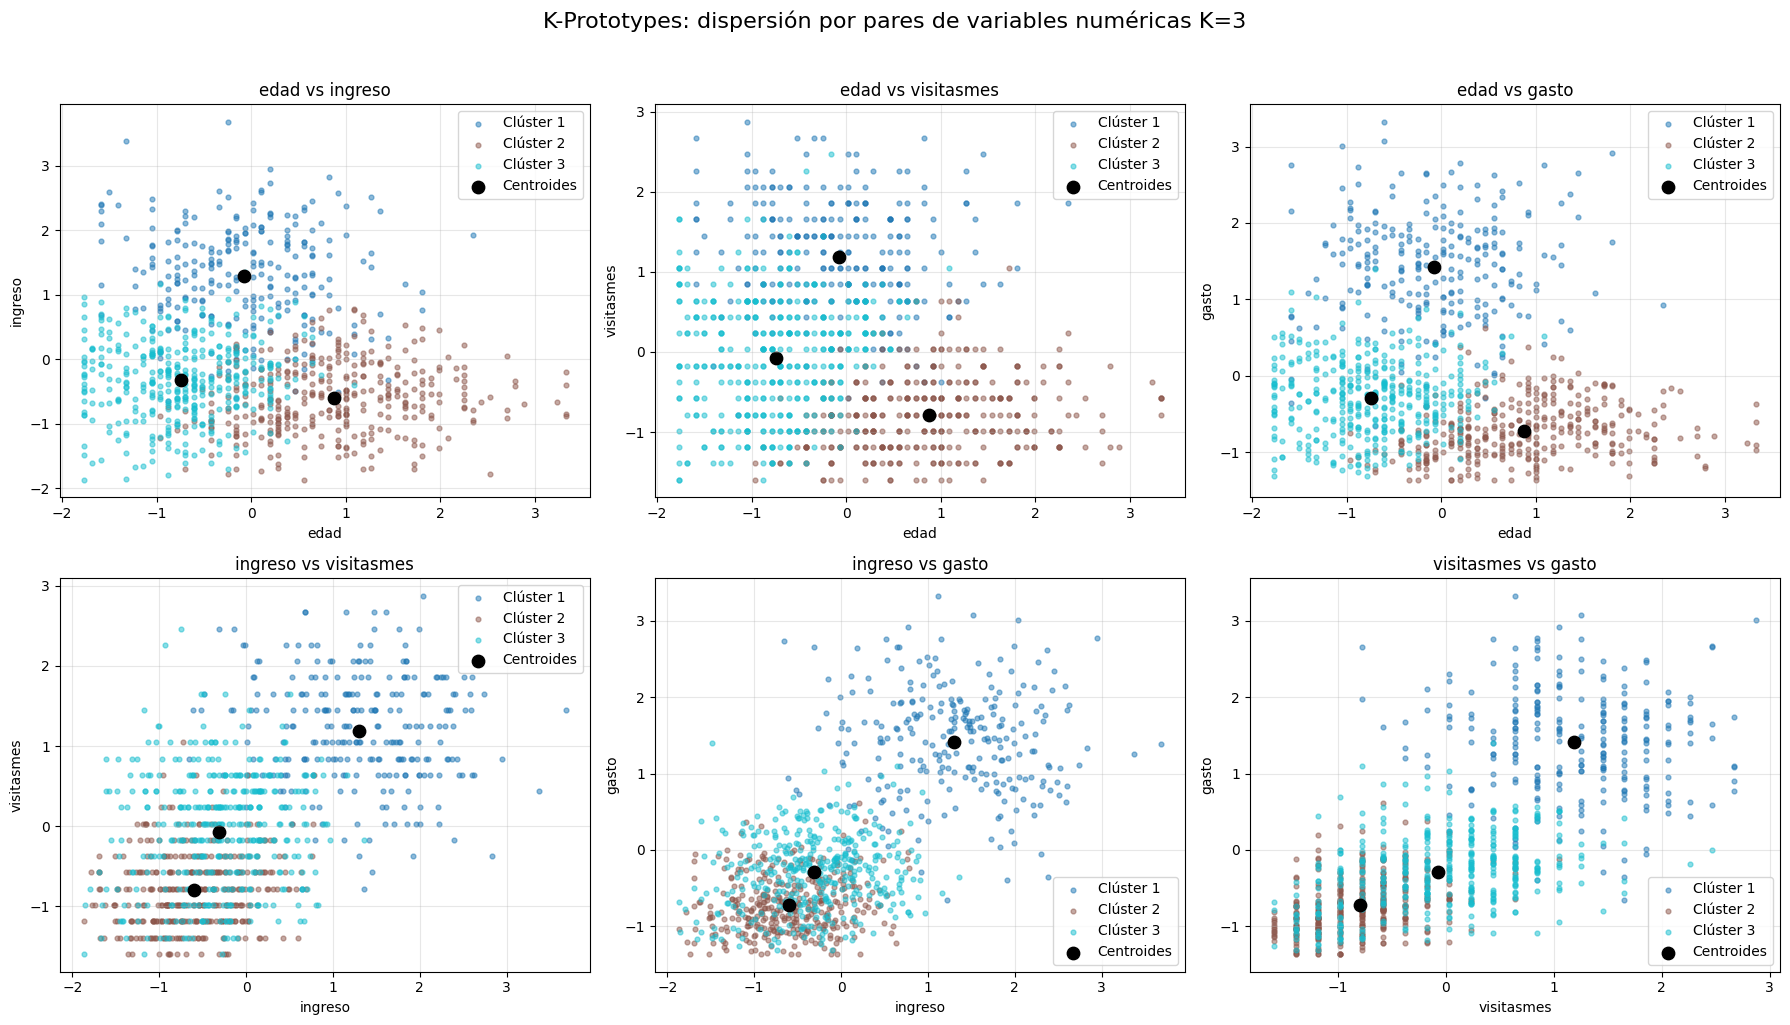

In [17]:
datos_visual = datos_kprototypesK3.copy()

datos_visual["cluster_prototype"] = modelo_KPrototypesK3["cluster"]

tabla_centroides = modelo_KPrototypesK3["prototipos_modelo"]

f_dispersion_variables_clusters(
    datos=datos_visual,
    variable_cluster="cluster_prototype",
    variables=variables_numericas,
    centroides=tabla_centroides[variables_numericas],
    titulo="K-Prototypes: dispersión por pares de variables numéricas K=3",
    ncol=3
)

plt.show()

### Diagramas de cajas K-Prototypes para variables numéricas K=3

En el diagrama de cajas para *K=3*, se corrobora que los valores altos en ingresos, las altas visitas promedio y los gastos altos definen el *clúster 1*; por el contrario los valores bajos definen el *cluster 2*.

El *clúster 3* tiene valores intermedios de estas variables numéricas, *ingreso*, *visitasmes* y *gasto*.




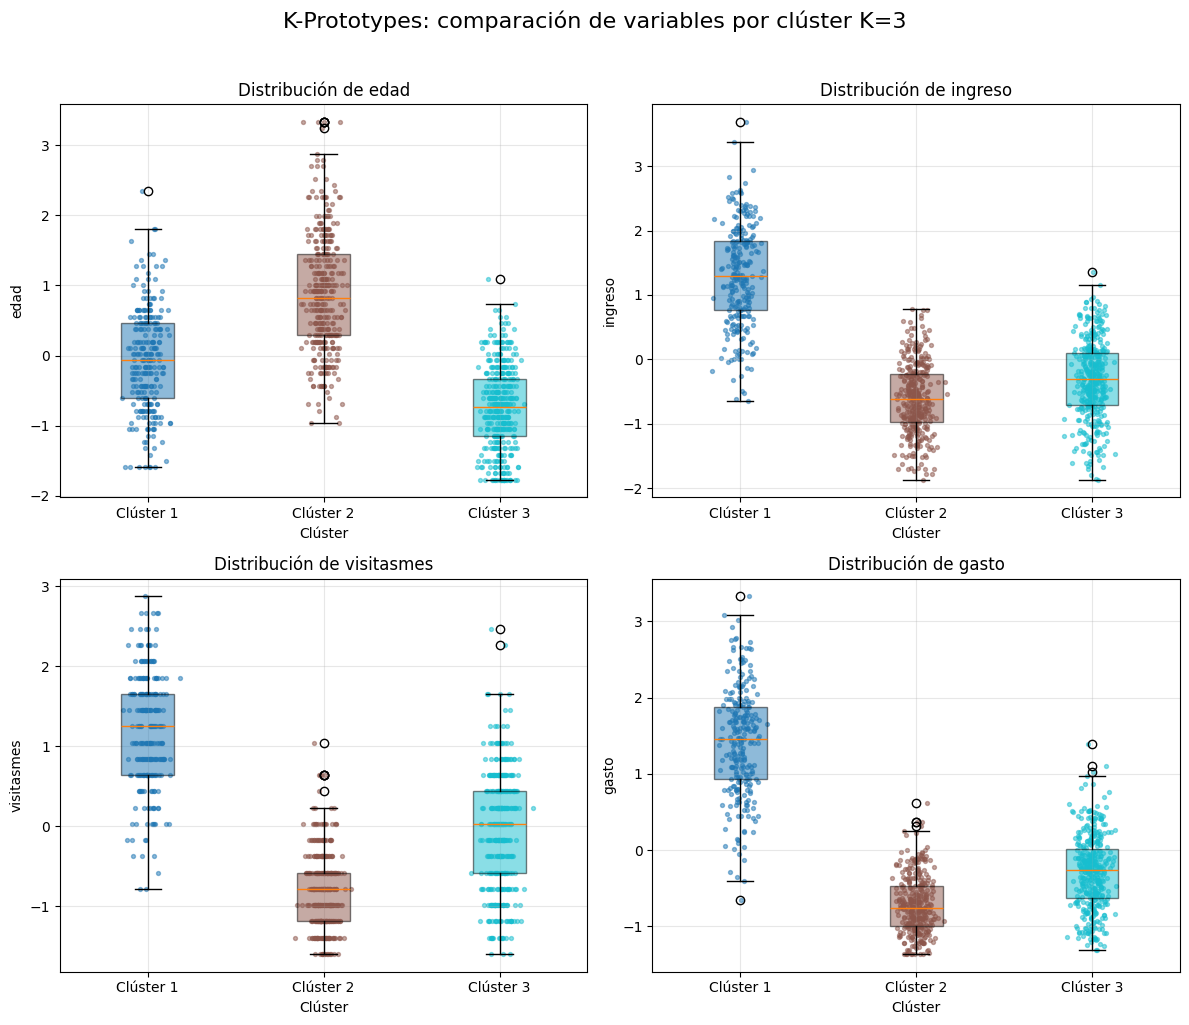

In [18]:
f_diagramas_cajas(
    datos=datos_kprototypesK3,
    variable_cluster="cluster_prototype",
    variables=variables_numericas,
    titulo="K-Prototypes: comparación de variables por clúster K=3",
    ncol=2
)

plt.show()

### Frecuencias de variables categóricas por cluster K=3



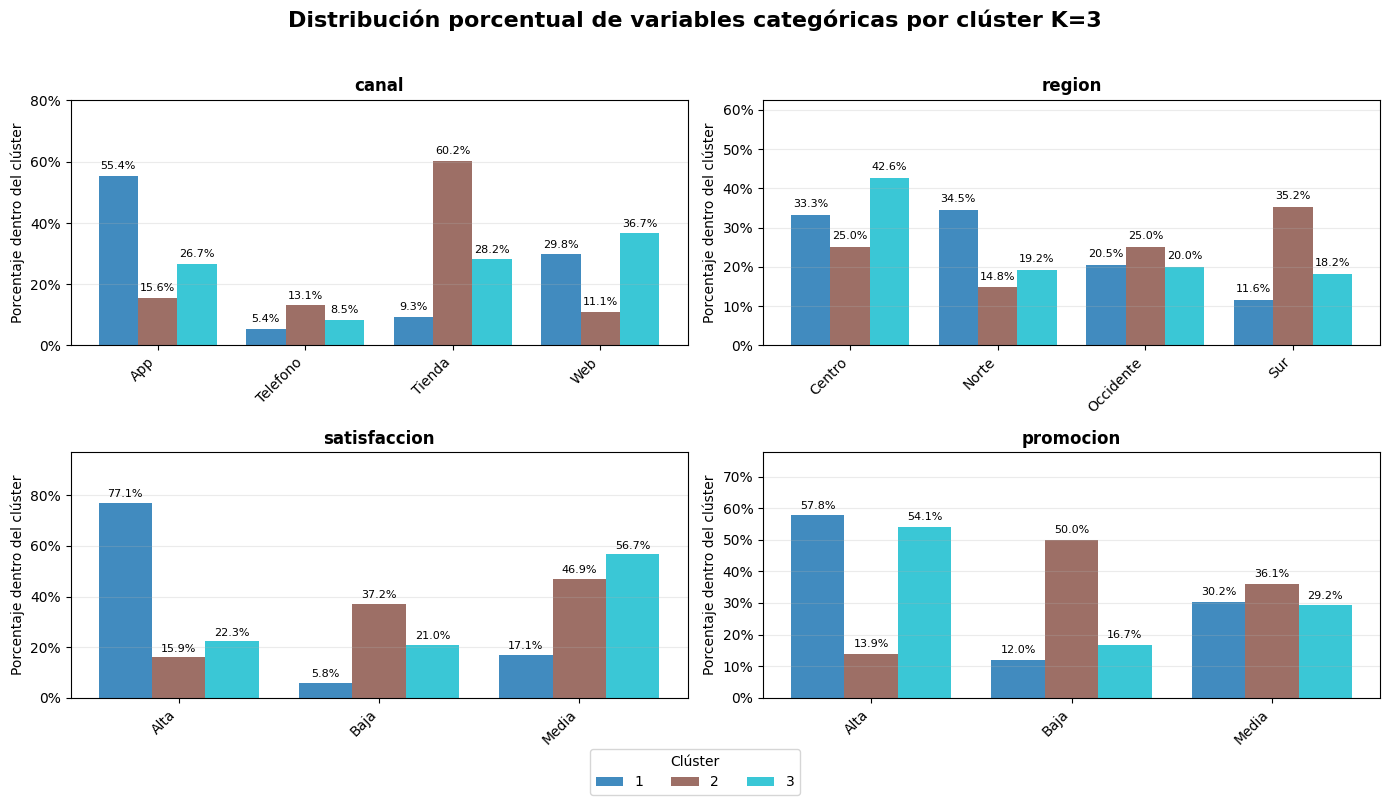

In [19]:
datos_visual = datos_kprototypesK3.copy()
cluster3 = modelo_KPrototypesK3.get("cluster")
datos_visual["cluster_KModesK3"] = cluster3

resultado_visual = f_visualizar_clusters_categoricos(
    datos=datos_visual,
    variable_cluster="cluster_KModesK3",
    variables=variables_categoricas,
    ncol=2,
    titulo="Distribución porcentual de variables categóricas por clúster K=3",
    posicion="dodge",
    mostrar_etiquetas=True,
    rotar_etiquetas=True
)

## Evaluación de modelos K-Prototypes


Se evalúan los modelos *K-Prototypes* con *K=2*, *K=3* y un siguiente modelo particularmente para evaluacuón con los otros dos con *K=4*.

Ya se tienen los modelos llamados *modelo_KPrototypesK2* y *modelo_KPrototypesK3*, ahora se construye el modelo para K=4 llamado *modelo_KPrototypesK4*.


In [ ]:
modelo_KPrototypesK4 = f_crear_KPrototypes(
    datos=datos_kprototypes,
    variables_numericas=variables_numericas,
    variables_categoricas=variables_categoricas,
    n_clusters=4,
    init="Huang",
    n_init=25,
    max_iter=100,
    gamma=None,
    random_state=2026,
    estandarizar=False, # Ya vienen estandarizados
    nombre_cluster="cluster_KPrototypes"
)

Se evalúan todos los modelos con la función *evaluacion_costo_KPrototypes()*.

Se evalúan todos los modelos con la función *evaluacion_costo_KPrototypes()*.

En la tabla se observa que a mayor número de clústeres definidos es menor el costo de disimilitud.

La pregunta es: ¿cuántos clústeres definir?, depende de la capacidad de comprensión y claridad que se den en los números de clústeres, si se es capaz de comprender las diferencias contextuales de cada clúster ese será el número adecuado.


In [ ]:
evaluacion_costo_KPrototypes = f_evaluar_costo_KPrototypes(
    modelos=[
        modelo_KPrototypesK2,
        modelo_KPrototypesK3,
        modelo_KPrototypesK4
    ],
    nombres_modelos=[
        "K-Prototypes K=2",
        "K-Prototypes K=3",
        "K-Prototypes K=4"
    ],
    graficar=True,
    titulo="Evaluación del costo en K-Prototypes K=2, K=3, K=4",
    reemplazar_NA=False
)

evaluacion_costo_KPrototypes["tabla_costos"]

# Interpretación del caso de estudio

Este caso de estudio cumple con el objetivo planteado de implementar un modelo de clustering dentro del aprendizaje no supervisados con datos relacionados con el comportamiento de compras de clientes.

El modelo implementado fue *K-Prototypes* que dentro de sus características,  es que trata con datos estructurados que contienen tanto variables numéricas como categóricas y combina las bondades del algoritmo *K-Means* y *K-Modes*.

El primer modelo *K-Prototypes* con dos clústeres definidos *K=2*, encuentra y define dos grupos de clientes, aquellos cuyos valores son altos en variables económicas tales como el ingreso, la cantidad de vistias promedio y el gasto promedio que realizan en sus compras; por otra parte un segundo grupso con valores a la inversa del primer grupo.

Con un segundo modelo *K-Prototypes* con tres clústeres *K=3*; el modelo es más fino en la definición de grupos, un primer clúster son aquellos clientes que tienen valores altos en sus las variables económicas y un segundo grupo los que no tienen esos valores, pero destaca un grupo intermedio que tiene valores moderados en sus variables.

El caso de estudio refleja una evaluación entre de los modelos encontrándose que el modelo *K=3* y *K=4* tienen menos costo de disimilitud entre los grupos.

Los resultados de este caso de estudio en *Python* son similares a los encontrados en programación *R*.    
